In [1]:
import os
import joblib

from sklearn.metrics import f1_score, multilabel_confusion_matrix, \
    classification_report, accuracy_score, hamming_loss

import numpy as np
import matplotlib.pyplot as plt

import torch

# LLR6 vanilla

## Datasets

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [3]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = True      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'vanilla' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [4]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [5]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [6]:
all_params[cond][200:300, :][0]

tensor([ 4.1880e-02, -7.5578e-01,  5.2582e-01, -3.2770e-02,  1.7373e-03,
        -3.3464e-01, -4.6585e-01, -4.3904e-01,  1.1167e-01,  5.7964e-01,
         1.8843e-01,  8.4085e-02, -3.0920e-02,  0.0000e+00,  5.1239e-01,
        -1.5643e-02,  0.0000e+00, -1.1611e+00,  5.2785e-01,  0.0000e+00,
         0.0000e+00, -1.9501e+00], dtype=torch.float64)

In [7]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7475, std: 0.0064
C=0.1 , l1=0.5, mean: 0.7497, std: 0.0059
C=0.1 , l1=1.0, mean: 0.7519, std: 0.0037 <--
C=1.0 , l1=0.0, mean: 0.7475, std: 0.0065
C=1.0 , l1=0.5, mean: 0.7475, std: 0.0063
C=1.0 , l1=1.0, mean: 0.7479, std: 0.0064
C=10.0, l1=0.0, mean: 0.7473, std: 0.0056
C=10.0, l1=0.5, mean: 0.7479, std: 0.0063
C=10.0, l1=1.0, mean: 0.7475, std: 0.0067


In [8]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7412, std: 0.0021
C=0.1 , l1=0.5, mean: 0.7408, std: 0.0022
C=0.1 , l1=1.0, mean: 0.7381, std: 0.0024 <--
C=1.0 , l1=0.0, mean: 0.7412, std: 0.0023
C=1.0 , l1=0.5, mean: 0.7410, std: 0.0022
C=1.0 , l1=1.0, mean: 0.7411, std: 0.0020
C=10.0, l1=0.0, mean: 0.7411, std: 0.0017
C=10.0, l1=0.5, mean: 0.7411, std: 0.0021
C=10.0, l1=1.0, mean: 0.7408, std: 0.0023


### Accuracies on all datasets

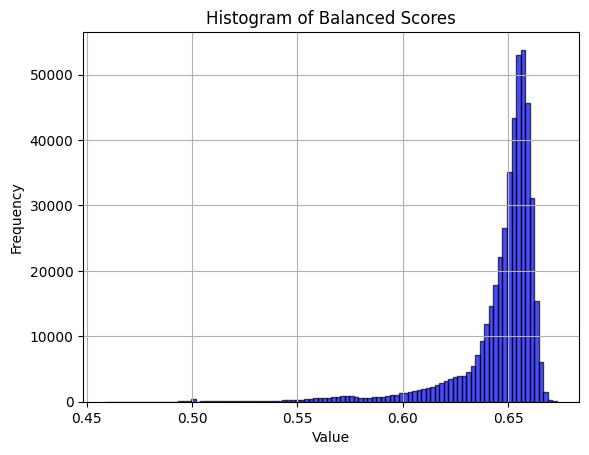

In [9]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

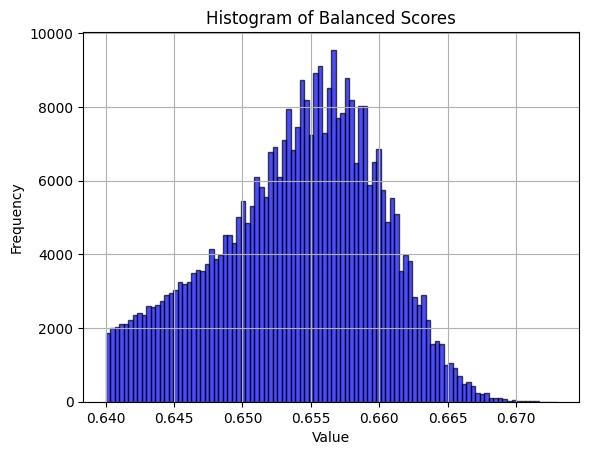

In [10]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [11]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [12]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [13]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7521
F1-score: 0.7762652450748239

Confusion Matrix for Class 0 - Chowell_train:
[[0.84206072 0.15793928]
 [0.05361884 0.94638116]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.80459347 0.19540653]
 [0.07670998 0.92329002]]

Confusion Matrix for Class 2 - MSK1:
[[0.76226415 0.23773585]
 [0.07838556 0.92161444]]

Confusion Matrix for Class 3 - MSK2:
[[0.71721334 0.28278666]
 [0.15114347 0.84885653]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.6435944  0.3564056 ]
 [0.31756684 0.68243316]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.43685998 0.56314002]
 [0.26646754 0.73353246]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.58723107 0.41276893]
 [0.34423591 0.65576409]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.72873333 0.27126667]
 [0.19351562 0.80648437]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.74634656 0.25365344]
 [0.32586892 0.67413108]]


              precision    recall  f1-score   support

           0       0.91      0.95   

### Strong (AUC scores)

In [14]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [15]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7999
F1-score: 0.8161078289501712

Confusion Matrix for Class 0 - Chowell_train:
[[0.99590959 0.00409041]
 [0.00894373 0.99105627]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.93083044 0.06916956]
 [0.00752235 0.99247765]]

Confusion Matrix for Class 2 - MSK1:
[[0.75290447 0.24709553]
 [0.01687245 0.98312755]]

Confusion Matrix for Class 3 - MSK2:
[[0.64238229 0.35761771]
 [0.22869352 0.77130648]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.80654512 0.19345488]
 [0.28441176 0.71558824]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.58313188 0.41686812]
 [0.32524401 0.67475599]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.58695166 0.41304834]
 [0.31651221 0.68348779]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.75827695 0.24172305]
 [0.16247396 0.83752604]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.88170668 0.11829332]
 [0.23457339 0.76542661]]


              precision    recall  f1-score   support

           0       1.00      0.99   

## White-box attack ensemble

In [16]:
aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [17]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 0.9168


In [18]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.9226125396785654

Confusion Matrix for Class 0 - Chowell_train:
[[9.97990056e-01 2.00994393e-03]
 [5.22261392e-04 9.99477739e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.9912744  0.0087256 ]
 [0.00560798 0.99439202]]

Confusion Matrix for Class 2 - MSK1:
[[0.96523548 0.03476452]
 [0.01581485 0.98418515]]

Confusion Matrix for Class 3 - MSK2:
[[0.98783034 0.01216966]
 [0.01255572 0.98744428]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.85438734 0.14561266]
 [0.14470588 0.85529412]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.79652316 0.20347684]
 [0.26468078 0.73531922]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.69631182 0.30368818]
 [0.12831296 0.87168704]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.91287278 0.08712722]
 [0.02723958 0.97276042]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.95472338 0.04527662]
 [0.06629067 0.93370933]]


              precision    recall  f1-score   support

           0       1.00      1.00    

### Evaluate LORIS

In [19]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [20]:
# ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
#  'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
#  'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
#  'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
#  'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

# S = 0.0371 * min(TMB, 50) - 0.8775 * PSTH + 0.5382 * Albumin - 0.033 * min(NLR, 25) + 0.0049 * min(Age, 85) + CTCT - 2.0886

# CTCT = - 0.3323 * Bladder - 0.3323 * Breast - 0.102 * Colorectal - 0.0079 * Endometrial + 0.55 * Esophageal + 0.2306 * Gastric
#     + 0.0678 * Head&Neck - 0.1189 * Hepatobiliary - 0.0086 * Melanoma + 0.1255 * Mesothelioma + 0.0008 * NSCLC
#     - 0.052 * Ovarian - 1.1169 * Pancreatic + 0.5451 * Renal + 0.0542 * Sarcoma - 0.0033 * SCLC

coeffs = [0.0371, -0.8775, 0.5382, -0.033, 0.0049, -0.3323, -0.3323, -0.102,
          -0.0079, 0.55, 0.2306, 0.0678, -0.1189, -0.0086, 0.1255, 0.0008,
          -0.052, -1.1169, 0.5451, 0.0542, -0.0033, -2.0886]
X_loris = torch.tensor(coeffs).unsqueeze(0)
X_loris

tensor([[ 3.7100e-02, -8.7750e-01,  5.3820e-01, -3.3000e-02,  4.9000e-03,
         -3.3230e-01, -3.3230e-01, -1.0200e-01, -7.9000e-03,  5.5000e-01,
          2.3060e-01,  6.7800e-02, -1.1890e-01, -8.6000e-03,  1.2550e-01,
          8.0000e-04, -5.2000e-02, -1.1169e+00,  5.4510e-01,  5.4200e-02,
         -3.3000e-03, -2.0886e+00]])

In [21]:
classify_by_dataset(loaded_models, X_loris)

   Chowell_train: 1.0000
    Chowell_test: 0.0097
            MSK1: 0.0333
            MSK2: 0.1326
      Shim_NSCLC: 0.0667
  Kato_panCancer: 0.2923
   Vanguri_NSCLC: 0.5164
      Ravi_NSCLC: 0.0064
Pradat_panCancer: 0.0230


### Check other models

In [22]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([185, 22])


tensor([[ 0.0520, -0.9925,  0.5170, -0.0573,  0.0212, -0.6566, -0.4690, -0.0942,
          0.1167,  0.8743,  0.4764,  0.3967, -0.3531, -0.2637,  0.4566,  0.1888,
         -0.3462, -5.8032,  0.8812,  0.3514, -0.4067, -2.9979]],
       dtype=torch.float64)

In [23]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 1.0000
    Chowell_test: 0.0768
            MSK1: 0.0300
            MSK2: 0.0000
      Shim_NSCLC: 0.9940
  Kato_panCancer: 0.8956
   Vanguri_NSCLC: 0.3076
      Ravi_NSCLC: 0.8265
Pradat_panCancer: 0.0162


# LLR6 average

## Datasets

In [24]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [25]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = True      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'average' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [26]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [27]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [28]:
all_params[cond][200:300, :][0]

tensor([ 3.5625e-02, -8.6805e-01,  5.1487e-01, -3.0641e-02,  4.4756e-03,
        -2.9795e-01, -2.8235e-01, -7.2376e-02,  2.7089e-03,  4.8952e-01,
         2.0883e-01,  5.7606e-02, -1.2260e-01, -8.6673e-03,  9.3944e-02,
         7.2984e-04, -6.2564e-02, -9.0208e-01,  4.9290e-01,  5.7316e-02,
        -1.0378e-02, -1.9780e+00], dtype=torch.float64)

In [29]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7508, std: 0.0003
C=0.1 , l1=0.5, mean: 0.7527, std: 0.0003
C=0.1 , l1=1.0, mean: 0.7551, std: 0.0005 <--
C=1.0 , l1=0.0, mean: 0.7490, std: 0.0004
C=1.0 , l1=0.5, mean: 0.7496, std: 0.0004
C=1.0 , l1=1.0, mean: 0.7504, std: 0.0004
C=10.0, l1=0.0, mean: 0.7478, std: 0.0005
C=10.0, l1=0.5, mean: 0.7480, std: 0.0005
C=10.0, l1=1.0, mean: 0.7481, std: 0.0006


In [30]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7442, std: 0.0001
C=0.1 , l1=0.5, mean: 0.7440, std: 0.0001
C=0.1 , l1=1.0, mean: 0.7406, std: 0.0002 <--
C=1.0 , l1=0.0, mean: 0.7437, std: 0.0001
C=1.0 , l1=0.5, mean: 0.7442, std: 0.0001
C=1.0 , l1=1.0, mean: 0.7443, std: 0.0001
C=10.0, l1=0.0, mean: 0.7433, std: 0.0001
C=10.0, l1=0.5, mean: 0.7434, std: 0.0001
C=10.0, l1=1.0, mean: 0.7434, std: 0.0001


### Accuracies on all datasets

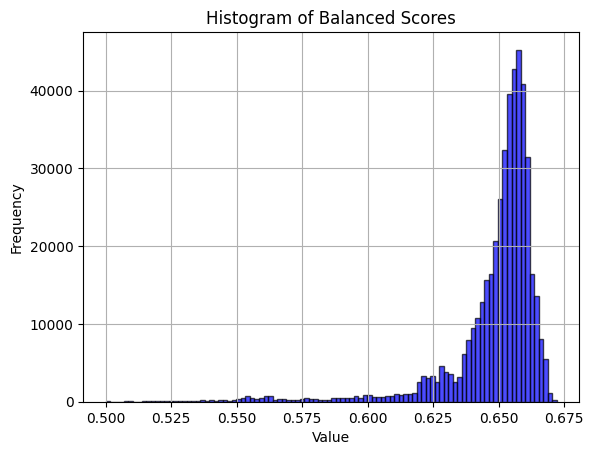

In [31]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

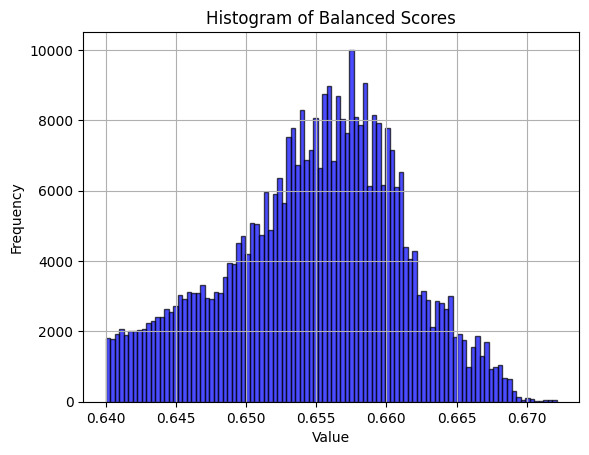

In [32]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [33]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [34]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [35]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8175
F1-score: 0.8332689553689908

Confusion Matrix for Class 0 - Chowell_train:
[[0.93080472 0.06919528]
 [0.00223757 0.99776243]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.94874187 0.05125813]
 [0.04042397 0.95957603]]

Confusion Matrix for Class 2 - MSK1:
[[0.95107955 0.04892045]
 [0.04716562 0.95283438]]

Confusion Matrix for Class 3 - MSK2:
[[0.38524373 0.61475627]
 [0.01641293 0.98358707]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.74722395 0.25277605]
 [0.19698222 0.80301778]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.55474318 0.44525682]
 [0.2707202  0.7292798 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.86935987 0.13064013]
 [0.53762792 0.46237208]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.81524231 0.18475769]
 [0.06794134 0.93205866]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.80828539 0.19171461]
 [0.14068112 0.85931888]]


              precision    recall  f1-score   support

           0       0.96      1.00   

### Strong (AUC scores)

In [36]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [37]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8971
F1-score: 0.9062276381422194

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[9.99315729e-01 6.84271096e-04]
 [3.99139632e-04 9.99600860e-01]]

Confusion Matrix for Class 2 - MSK1:
[[9.98492972e-01 1.50702797e-03]
 [1.40373862e-04 9.99859626e-01]]

Confusion Matrix for Class 3 - MSK2:
[[0.71216782 0.28783218]
 [0.23878408 0.76121592]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.98344749 0.01655251]
 [0.01147168 0.98852832]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.57988586 0.42011414]
 [0.1170682  0.8829318 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.51874483 0.48125517]
 [0.04432878 0.95567122]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.94482349 0.05517651]
 [0.11526875 0.88473125]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.99388825 0.00611175]
 [0.07327688 0.92672312]]


              precision    recall  f1-score   support

           0       1.00      1.00   

## White-box attack ensemble

In [38]:
aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [39]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 1.0000


In [40]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.9999851119379249

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 2 - MSK1:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 3 - MSK2:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[1.00000000e+00 0.00000000e+00]
 [5.16742456e-05 9.99948326e-01]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[9.99894801e-01 1.05199485e-04]
 [5.09878904e-05 9.99949012e-01]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[9.99973317e-01 2.66830323e-05]
 [2.51439491e-05 9.99974856e-01]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[1.00000000e+00 0.00000000e+00]
 [2.48960590e-05 9.99975104e-01]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[1. 0.]
 [0. 1.]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     46032
           1       1.00      1.00      1.00     45097
           2       1.00      1.00      1.

### Evaluate LORIS

In [41]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [42]:
# ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
#  'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
#  'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
#  'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
#  'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

# S = 0.0371 * min(TMB, 50) - 0.8775 * PSTH + 0.5382 * Albumin - 0.033 * min(NLR, 25) + 0.0049 * min(Age, 85) + CTCT - 2.0886

# CTCT = - 0.3323 * Bladder - 0.3323 * Breast - 0.102 * Colorectal - 0.0079 * Endometrial + 0.55 * Esophageal + 0.2306 * Gastric
#     + 0.0678 * Head&Neck - 0.1189 * Hepatobiliary - 0.0086 * Melanoma + 0.1255 * Mesothelioma + 0.0008 * NSCLC
#     - 0.052 * Ovarian - 1.1169 * Pancreatic + 0.5451 * Renal + 0.0542 * Sarcoma - 0.0033 * SCLC

coeffs = [0.0371, -0.8775, 0.5382, -0.033, 0.0049, -0.3323, -0.3323, -0.102,
          -0.0079, 0.55, 0.2306, 0.0678, -0.1189, -0.0086, 0.1255, 0.0008,
          -0.052, -1.1169, 0.5451, 0.0542, -0.0033, -2.0886]
X_loris = torch.tensor(coeffs).unsqueeze(0)
X_loris

tensor([[ 3.7100e-02, -8.7750e-01,  5.3820e-01, -3.3000e-02,  4.9000e-03,
         -3.3230e-01, -3.3230e-01, -1.0200e-01, -7.9000e-03,  5.5000e-01,
          2.3060e-01,  6.7800e-02, -1.1890e-01, -8.6000e-03,  1.2550e-01,
          8.0000e-04, -5.2000e-02, -1.1169e+00,  5.4510e-01,  5.4200e-02,
         -3.3000e-03, -2.0886e+00]])

In [43]:
classify_by_dataset(loaded_models, X_loris)

   Chowell_train: 1.0000
    Chowell_test: 0.0000
            MSK1: 0.0000
            MSK2: 0.0000
      Shim_NSCLC: 0.0000
  Kato_panCancer: 0.0000
   Vanguri_NSCLC: 0.0004
      Ravi_NSCLC: 0.0000
Pradat_panCancer: 0.0000


### Check other models

In [44]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([186, 22])


tensor([[ 0.0481, -0.9245,  0.5292, -0.0520,  0.0126, -0.7236, -1.0088, -0.4855,
         -0.1434,  0.8207,  0.3509,  0.2465, -0.5546, -0.2092,  0.4096,  0.0384,
         -0.3256, -3.5517,  0.7787,  0.3397, -0.0754, -2.4505]],
       dtype=torch.float64)

In [45]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 1.0000
    Chowell_test: 0.0000
            MSK1: 0.0000
            MSK2: 0.0000
      Shim_NSCLC: 1.0000
  Kato_panCancer: 1.0000
   Vanguri_NSCLC: 0.0006
      Ravi_NSCLC: 0.0000
Pradat_panCancer: 0.0000


# TT vanilla

## Datasets

In [46]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [47]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = False      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'vanilla' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [48]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [49]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [50]:
all_params[cond][200:300, :][0]

tensor([ 1.6946e+00,  1.3897e-01,  1.8090e+00,  2.4309e+00, -1.1462e-01,
        -7.4934e-02, -6.5371e-02, -6.3587e-02,  8.7248e-02,  5.7632e-02,
         4.8910e-02,  4.7591e-02, -1.0352e+00,  1.1717e+01, -7.9453e-01,
         2.3362e+00,  2.2588e+00, -1.5963e+01,  7.3965e-01, -2.1124e+00,
         7.0105e-01, -1.0423e+00,  6.3817e-03, -1.5915e-02,  1.2776e-01,
        -1.0240e-01,  2.1868e-03, -5.3087e-03, -2.2441e+00, -2.8409e+00,
         4.0136e-03,  2.7503e-03,  2.2325e-01, -3.9239e-01,  1.6607e-03,
         1.1590e-03, -5.0670e+00,  1.5441e+00,  8.8521e-01, -5.6911e-01,
         4.2950e+00, -3.0732e-01, -1.2593e+00,  8.0018e-01,  9.1174e-01,
        -2.6359e-01, -6.5482e-01, -6.6357e-01, -8.0871e-01, -2.6945e+00,
        -9.7915e-01, -9.8306e-01, -4.0132e-01,  3.9712e-01, -3.5401e-02,
         1.8187e-03,  4.6112e-01, -3.9474e-01,  3.2194e-02, -4.3277e-04,
        -5.8330e+00,  7.6013e+00,  2.5788e-02, -3.9778e-02, -6.5520e+00,
         9.3930e+00, -9.2603e-02,  1.1303e-01,  1.8

In [51]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7465, std: 0.0056
C=0.1 , l1=0.5, mean: 0.7487, std: 0.0052
C=0.1 , l1=1.0, mean: 0.7510, std: 0.0036 <--
C=1.0 , l1=0.0, mean: 0.7461, std: 0.0054
C=1.0 , l1=0.5, mean: 0.7465, std: 0.0054
C=1.0 , l1=1.0, mean: 0.7468, std: 0.0053
C=10.0, l1=0.0, mean: 0.7459, std: 0.0052
C=10.0, l1=0.5, mean: 0.7464, std: 0.0054
C=10.0, l1=1.0, mean: 0.7462, std: 0.0059


In [52]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7402, std: 0.0019
C=0.1 , l1=0.5, mean: 0.7399, std: 0.0020
C=0.1 , l1=1.0, mean: 0.7376, std: 0.0023 <--
C=1.0 , l1=0.0, mean: 0.7397, std: 0.0022
C=1.0 , l1=0.5, mean: 0.7395, std: 0.0019
C=1.0 , l1=1.0, mean: 0.7397, std: 0.0019
C=10.0, l1=0.0, mean: 0.7393, std: 0.0018
C=10.0, l1=0.5, mean: 0.7396, std: 0.0019
C=10.0, l1=1.0, mean: 0.7394, std: 0.0022


### Accuracies on all datasets

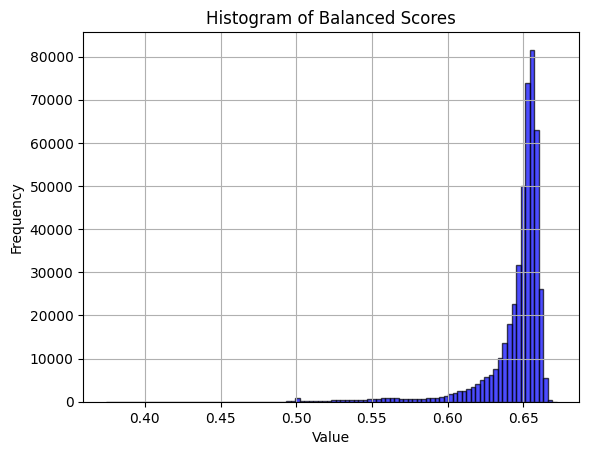

In [53]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

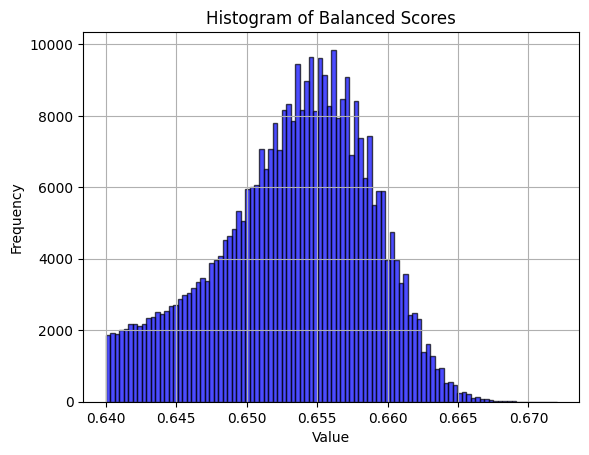

In [54]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [55]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [56]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [57]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7406
F1-score: 0.7673626083959095

Confusion Matrix for Class 0 - Chowell_train:
[[0.75420645 0.24579355]
 [0.0547373  0.9452627 ]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.73787858 0.26212142]
 [0.08213608 0.91786392]]

Confusion Matrix for Class 2 - MSK1:
[[0.68604442 0.31395558]
 [0.17879645 0.82120355]]

Confusion Matrix for Class 3 - MSK2:
[[0.76158468 0.23841532]
 [0.15261195 0.84738805]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.64859383 0.35140617]
 [0.31022074 0.68977926]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.51218441 0.48781559]
 [0.36247318 0.63752682]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.60927282 0.39072718]
 [0.33570562 0.66429438]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.70559761 0.29440239]
 [0.14950114 0.85049886]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.65999842 0.34000158]
 [0.22043596 0.77956404]]


              precision    recall  f1-score   support

           0       0.86      0.95   

### Strong (AUC scores)

In [58]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [59]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7835
F1-score: 0.7957775313486309

Confusion Matrix for Class 0 - Chowell_train:
[[0.98011169 0.01988831]
 [0.01847058 0.98152942]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.9436371  0.0563629 ]
 [0.01296648 0.98703352]]

Confusion Matrix for Class 2 - MSK1:
[[0.69322876 0.30677124]
 [0.10514958 0.89485042]]

Confusion Matrix for Class 3 - MSK2:
[[0.83464567 0.16535433]
 [0.30849722 0.69150278]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.84839099 0.15160901]
 [0.36838713 0.63161287]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.54903952 0.45096048]
 [0.33267167 0.66732833]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.43368174 0.56631826]
 [0.20251463 0.79748537]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.84952016 0.15047984]
 [0.30046875 0.69953125]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.9165765  0.0834235 ]
 [0.33453348 0.66546652]]


              precision    recall  f1-score   support

           0       0.99      0.98   

## White-box attack ensemble

In [60]:
aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [61]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 0.5370


In [62]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.6744210449332091

Confusion Matrix for Class 0 - Chowell_train:
[[0. 1.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[3.39535515e-05 9.99966046e-01]
 [4.51793621e-05 9.99954821e-01]]

Confusion Matrix for Class 2 - MSK1:
[[1.19738969e-04 9.99880261e-01]
 [2.48052786e-05 9.99975195e-01]]

Confusion Matrix for Class 3 - MSK2:
[[0.00255151 0.99744849]
 [0.00270988 0.99729012]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.00348117 0.99651883]
 [0.00367904 0.99632096]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.00128979 0.99871021]
 [0.00150215 0.99849785]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[4.75099212e-04 9.99524901e-01]
 [6.32611102e-04 9.99367389e-01]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[1.40714266e-04 9.99859286e-01]
 [2.88056145e-04 9.99711944e-01]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[9.99340213e-01 6.59787285e-04]
 [9.99497614e-01 5.02386335e-04]]


              precision    recall  f1-score   support

     

### Evaluate models

In [63]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [64]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([178, 168])


tensor([[ 7.7575e-01, -1.9634e+00,  3.1248e-01, -6.8208e-01,  1.7382e+00,
          7.2153e-01,  3.4520e+00,  4.0752e-01,  7.7233e-01,  3.2758e-01,
          1.5752e+00,  1.8603e-01,  7.6923e-01, -2.9698e-02,  5.1297e-02,
         -4.6359e-02, -2.7511e+00, -2.2798e+00, -6.5600e-01,  5.0656e-01,
          1.0181e+00, -2.4297e-01, -4.3220e-02,  8.4395e-03, -1.5264e+00,
          2.3957e-01, -7.1616e-02,  1.4140e-02,  8.1117e-01, -6.4550e-01,
          6.3875e-03,  6.3634e-04,  5.3352e+00, -3.1688e+00,  3.2110e-02,
          3.3928e-03,  9.3566e-01, -4.9147e-01, -9.0575e-02,  1.8130e-01,
         -2.9403e-01, -6.2389e+00,  7.5024e-01, -7.7901e-01, -1.5220e-01,
          5.3800e-01,  3.7114e-01,  9.6511e-02,  5.6623e-01,  5.4992e-01,
          1.1325e-01,  4.5656e-03,  9.1494e-01, -1.1392e+00, -6.5331e-02,
          5.4210e-02, -2.8171e-01,  1.0696e+00,  1.8259e-01, -1.8714e-01,
          2.4455e+00,  5.3658e-01, -2.3995e-02,  1.1034e-02,  8.9026e-01,
          1.0815e+00, -2.1250e-02,  8.

In [65]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 0.6254
    Chowell_test: 0.5979
            MSK1: 0.5468
            MSK2: 0.5045
      Shim_NSCLC: 0.5004
  Kato_panCancer: 0.5039
   Vanguri_NSCLC: 0.5158
      Ravi_NSCLC: 0.5186
Pradat_panCancer: 0.4872
